<a href="https://colab.research.google.com/github/Killian091/Machine_Learning/blob/main/Batch_Normalization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Batch Normalization**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
import pandas as pd
from sklearn.datasets import make_blobs
# Generate mixed data with two centers for a two-class dataset, with some mixing
X_generated, y_generated = make_blobs(n_samples=500, centers=2, cluster_std=3.0, random_state=42)
df = pd.DataFrame(X_generated, columns=['X', 'Y'])
df['class'] = y_generated

df.to_csv('mixed_class.csv', index=False)

df.head()

,X,Y,class
0,-3.946720,8.457309,0
1,-7.054771,13.114909,0
2,-5.433243,11.375540,0
3,-2.892950,6.147665,0
4,1.791682,9.870316,1


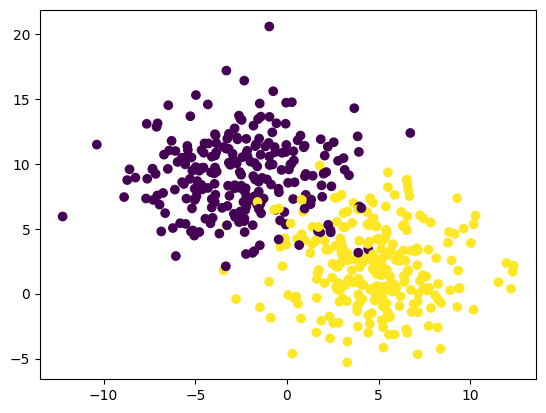

In [ ]:
plt.scatter(df['X'], df['Y'], c=df['class'])

In [ ]:
import tensorflow
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense
from tensorflow.keras.layers import BatchNormalization

In [ ]:
model = Sequential()

model.add(Dense(2, activation='relu', input_dim=2))
model.add(Dense(2, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 2)              │             6 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │             6 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15 (60.00 B)

 Trainable params: 15 (60.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [ ]:
X = df.iloc[:,0:2].values
y = df.iloc[:,2].values

history1 = model.fit(X, y, epochs=200, validation_split=0.2)

Epoch 1/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.6325 - loss: 0.6842 - val_accuracy: 0.4900 - val_loss: 0.6828
Epoch 2/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5025 - loss: 0.6782 - val_accuracy: 0.9000 - val_loss: 0.6784
Epoch 3/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9400 - loss: 0.6715 - val_accuracy: 0.9000 - val_loss: 0.6760
Epoch 4/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9350 - loss: 0.6651 - val_accuracy: 0.9200 - val_loss: 0.6740
Epoch 5/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9350 - loss: 0.6584 - val_accuracy: 0.9200 - val_loss: 0.6707
Epoch 6/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9350 - loss: 0.6534 - val_accuracy: 0.9100 - val_loss: 0.6688
Epoch 7/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9250 - loss: 0.6494 - val_accuracy: 0.9000 - val_loss: 0.6665
Epoch 8/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9250 - loss: 0.6454 - val_accuracy: 0.9100 - 

In [ ]:
model = Sequential()

model.add(Dense(3, activation='relu', input_dim=2))
model.add(BatchNormalization())
model.add(Dense(2, activation='relu'))
model.add(BatchNormalization())
model.add(Dense(1, activation='sigmoid'))

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 3)              │             9 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 3)              │            12 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 2)              │             8 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 2)              │             8 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40 (160.00 B)

 Trainable params: 30 (120.00 B)

 Non-trainable params: 10 (40.00 B)

In [ ]:
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [ ]:
history2 = model.fit(X, y, epochs=200, validation_split=0.2)

Epoch 1/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - accuracy: 0.1050 - loss: 1.0406 - val_accuracy: 0.1100 - val_loss: 0.7206
Epoch 2/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.0875 - loss: 1.0221 - val_accuracy: 0.1100 - val_loss: 0.7330
Epoch 3/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.0950 - loss: 0.9974 - val_accuracy: 0.1100 - val_loss: 0.7403
Epoch 4/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.1000 - loss: 0.9745 - val_accuracy: 0.1200 - val_loss: 0.7446
Epoch 5/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.0950 - loss: 0.9593 - val_accuracy: 0.1100 - val_loss: 0.7463
Epoch 6/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.1225 - loss: 0.9374 - val_accuracy: 0.1300 - val_loss: 0.7465
Epoch 7/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.1075 - loss: 0.9230 - val_accuracy: 0.1300 - val_loss: 0.7440
Epoch 8/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.1175 - loss: 0.9017 - val_accuracy: 0.13

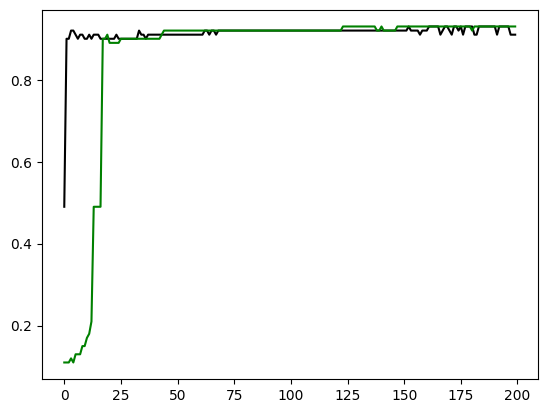

In [ ]:
plt.plot(history1.history['val_accuracy'],color='black')
plt.plot(history2.history['val_accuracy'],color='green')

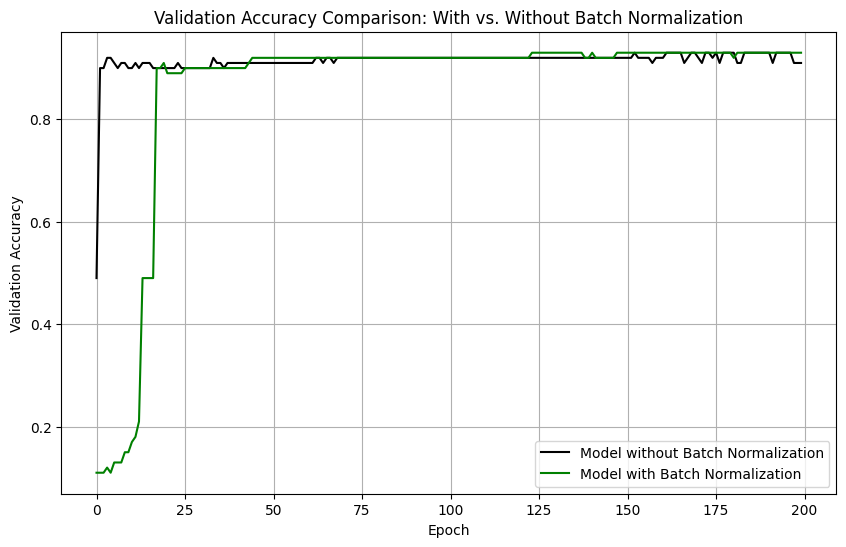

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(history1.history['val_accuracy'], label='Model without Batch Normalization', color='black')
plt.plot(history2.history['val_accuracy'], label='Model with Batch Normalization', color='green')
plt.title('Validation Accuracy Comparison: With vs. Without Batch Normalization')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.legend()
plt.grid(True)
plt.show()

### Why Batch Normalization might not show immediate advantages:

1.  **Simple Dataset/Network:** For relatively simple datasets and shallow networks, Batch Normalization might not offer significant improvements, or its benefits might be masked by other factors.
2.  **Learning Rate:** Batch Normalization often allows for higher learning rates. If the learning rate is not adjusted after adding Batch Normalization, the model might struggle to converge or even diverge.
3.  **Small Batch Size:** Batch Normalization's effectiveness can decrease with very small batch sizes because the statistics (mean and variance) estimated from the batch become less representative of the entire dataset.
4.  **Regularization Effect:** Batch Normalization has a slight regularization effect. If other regularization techniques are already heavily applied, adding Batch Normalization might lead to over-regularization.
5.  **Initialization:** The weight initialization might be already optimal for the network without Batch Normalization, and the benefits of BN in stabilizing training might not be immediately apparent without further tuning.

In your case, the initial plot suggests that the model without Batch Normalization reached a higher validation accuracy more quickly and maintained it, while the model with Batch Normalization started with very low accuracy and took longer to improve, eventually reaching a similar level. This could indicate an issue with the learning rate or other hyperparameters not being optimized for the Batch Normalization layers.